<a href="https://colab.research.google.com/github/williamorban/williamorban/blob/main/FinalSolas2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import kagglehub
gasparlarrainvaras_notre_dame_data_club_2026_historical_data_path = kagglehub.dataset_download('gasparlarrainvaras/notre-dame-data-club-2026-historical-data')

print('Data source import complete.')


Using Colab cache for faster access to the 'notre-dame-data-club-2026-historical-data' dataset.
Data source import complete.


In [ ]:
import numpy as np
import pandas as pd
import os

dataclub = gasparlarrainvaras_notre_dame_data_club_2026_historical_data_path
df = pd.DataFrame()

# List contents of the directory
# In case more tables are added to the dataset, this will display all the ones available.
print(f"Contents of {dataclub}:")
for dirname, _, filenames in os.walk(dataclub):
    for filename in filenames:
        print(os.path.join(dirname, filename))


csv_files = [f for f in os.listdir(dataclub) if f.endswith('.csv')]

## For this example we will take the ApplicationData.csv
if csv_files:
    file_path = os.path.join(dataclub, "ApplicationData.csv")
    df = pd.read_csv(file_path)
    print(f"Successfully loaded {file_path}:")

Contents of /kaggle/input/notre-dame-data-club-2026-historical-data:
/kaggle/input/notre-dame-data-club-2026-historical-data/ApplicationData.csv
Successfully loaded /kaggle/input/notre-dame-data-club-2026-historical-data/ApplicationData.csv:


Successfully loaded /kaggle/input/notre-dame-data-club-2026-historical-data/ApplicationData.csv:


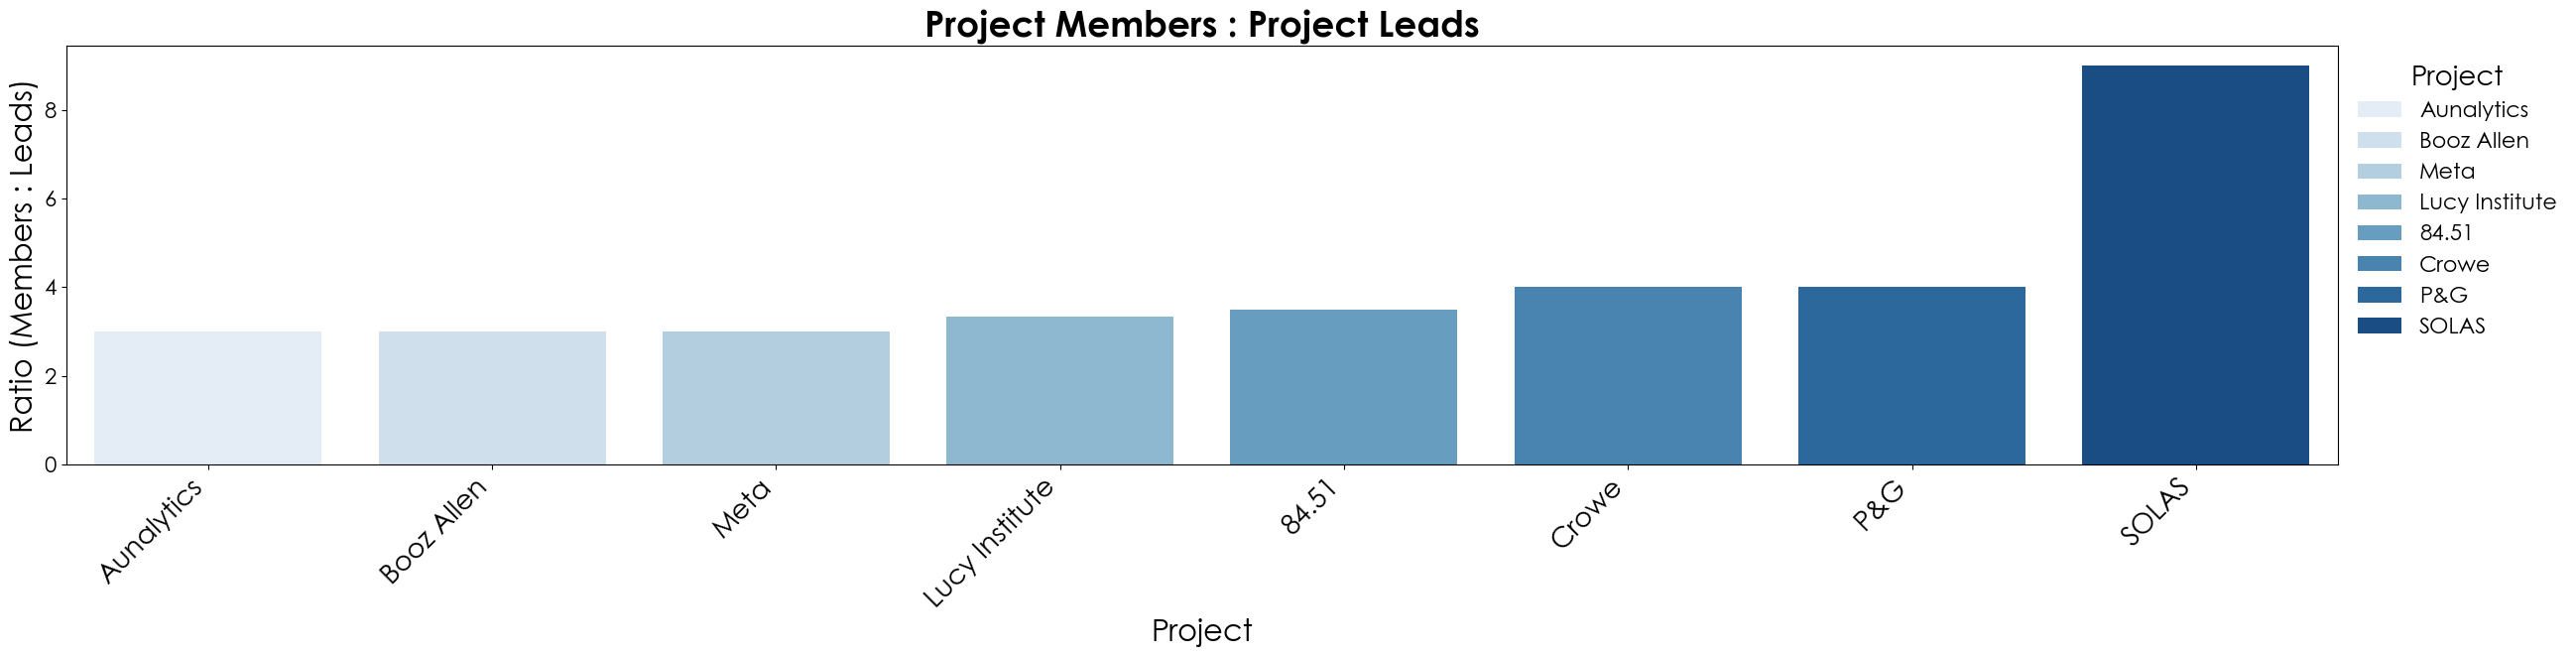

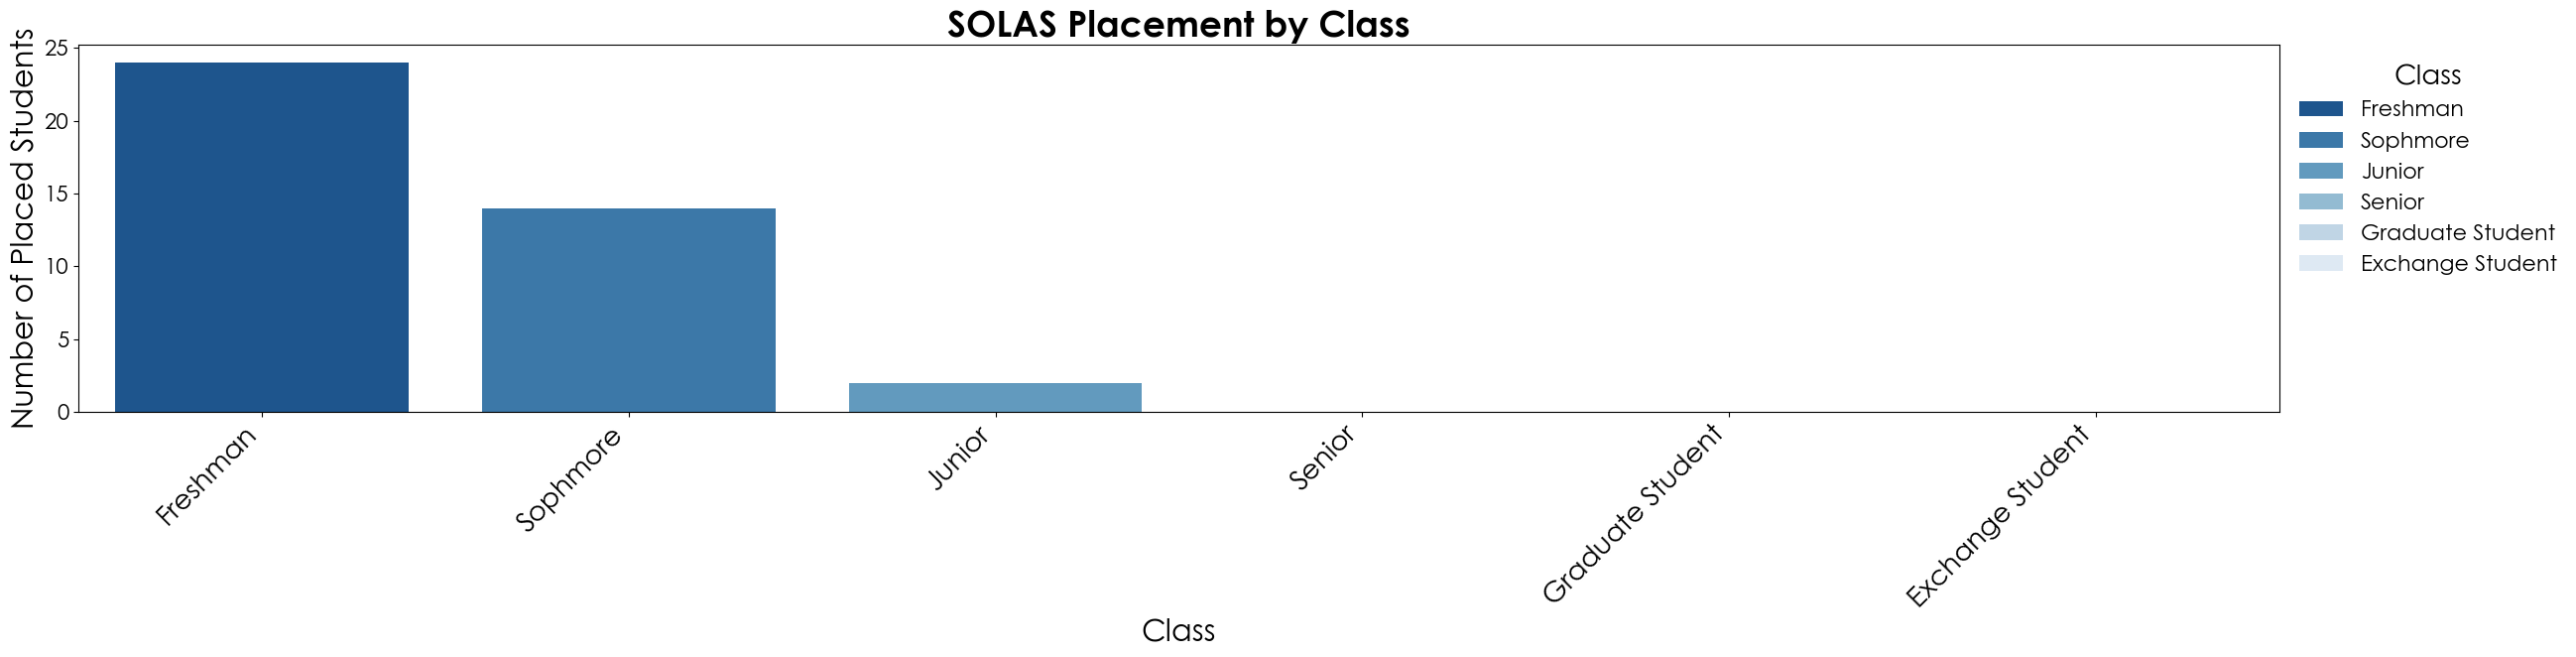

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os


dataclub = gasparlarrainvaras_notre_dame_data_club_2026_historical_data_path
df = pd.DataFrame()

csv_files = [f for f in os.listdir(dataclub) if f.endswith('.csv')]
if csv_files:
    file_path = os.path.join(dataclub, "ApplicationData.csv")
    df = pd.read_csv(file_path)
    print(f"Successfully loaded {file_path}:")

df.columns = df.columns.str.strip() #remove whitespace from column headers (namely second major)

# matplotlib/seaboard/matplotlib setup:
import seaborn as sns
import matplotlib.font_manager as fm

# 1. Point to your uploaded file (replace 'century_gothic.ttf' with your actual filename)
cg_path = '/content/fonts/centurygothic.ttf'
cg_bold_path = '/content/fonts/centurygothic_bold.ttf'
fm.fontManager.addfont(cg_path)
fm.fontManager.addfont(cg_bold_path)

# 3. Get the actual font name from the file metadata
cg_prop = fm.FontProperties(fname=cg_path)
cg_bold_prop = fm.FontProperties(fname=cg_bold_path)
cg = cg_prop.get_name()
cg_bold = cg_bold_prop.get_name()

# 4. Set as the global default
plt.rcParams['font.family'] = cg
plt.rcParams['xtick.labelsize'] = 16
plt.rcParams['ytick.labelsize'] = 16



# maybeMe = df[(df['Major'].str.lower().str.strip() == "computer science") & (df['Extra_fields_of_study'].str.lower().str.strip() == "economics")].copy()
# print(maybeMe)



# 0. Filter for the most recent semester (Spring 2026)
SP26 = df[(df['Year'] == 2026) & (df['Semester'] == 'Spring')].copy()

# I. CALCULATIONS

# 1. RATIO

# (a) Get all unique projects
projects = pd.concat((SP26['Selection_1'], SP26['Selection_2'], SP26['Selection_3'])).unique()
projects = np.delete(projects, -1) #removes NaN value

# (b) Iterate through projects and calculate member:project leader ratio

# projectMemberRatios = pd.DataFrame()
# for proj in projects:
#   acceptedCount = len(SP26[(SP26['Result'] == proj) & (SP26['Role'] == 1)])
#   print(acceptedCount)
#   if acceptedCount == 0: continue #done for palantir project which did not occur
#   PLCount = len(SP26[(SP26['Result'] == proj) & (SP26['Role'] == 2)])
#   ratio = acceptedCount/PLCount
#   projectMemberRatios['Project'] = proj
#   projectMemberRatios['Ratio'] = ratio
# print(projectMemberRatios)

# Count roles per project
counts = SP26.groupby(['Result', 'Role']).size().unstack(fill_value=0)

# Rename columns for clarity (assuming Role 1 is Member and Role 2 is PL)
counts = counts.rename(columns={1: 'Members', 2: 'PLs'})

# Filter out projects with 0 members and calculate ratio
counts = counts[counts['Members'] > 0]
counts['Ratio'] = counts['Members'] / counts['PLs']

# Reset index to get 'Project' as a column
projectMemberRatios = counts[['Ratio']].reset_index().rename(columns={'Result': 'Project'})

# print(projectMemberRatios)

projectMemberRatios = projectMemberRatios.sort_values(by='Ratio', ascending=True)

#----------------------------------#

# 2. SOLAS CLASS DISTRIBUTION

all_classes = [0, 1, 3, 4, 5, 6]
classes = ['Freshman', 'Sophmore', 'Junior', 'Senior', 'Graduate Student', 'Exchange Student']

# 1. Perform the grouping (using a copy or temporary categorical logic)
solas_counts = (
    SP26[SP26['Result'] == 'SOLAS']
    .groupby('Class', observed=False)
    .size()
    .reindex(all_classes, fill_value=0) # Ensures all 0, 1, 3... are present
)

# 2. Convert to DataFrame and reset index to get "class" and "count" columns
solasG = solas_counts.reset_index()
solasG.columns = ['Class', 'Count']

# 3. Map the integers to your string labels
class_map = dict(zip(all_classes, classes)) #dictionary to link
solasG['Class'] = solasG['Class'].map(class_map)


# II. VISUALIZATION
fig_size = (8.69*3, 2.24*3)

# 1. RATIO
plt.figure(figsize=fig_size)
plt.rcParams['xtick.labelsize'] = 20
ax = sns.barplot(
    data=projectMemberRatios,
    x='Project',
    y='Ratio',
    hue='Project',
    palette='Blues',
    legend=True
)

ax.set_title('Project Members : Project Leads (SP26)', fontproperties=cg_bold_prop, fontsize=26)
ax.set_xlabel('Project', fontsize=22)
ax.set_ylabel('Ratio (Members : Leads)', fontsize=22)

sns.move_legend(
    ax,
    "upper left",
    bbox_to_anchor=(1, 1),
    title="Project",
    fontsize=16,
    title_fontsize=20,
    frameon=False  # Optional: makes it look cleaner with many items
)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('ratioAnalysis.png')
plt.show()
plt.close()
# 2. CLASS

plt.figure(figsize=fig_size)
ax = sns.barplot(
    data=solasG,
    x='Class',
    y='Count',
    hue='Class',
    palette='Blues_r',
    legend=True
)

ax.set_title('SOLAS Placement by Class (SP26)', fontproperties=cg_bold_prop, fontsize=26)
ax.set_xlabel('Class', fontsize=22)
ax.set_ylabel('Number of Placed Students', fontsize=22)

sns.move_legend(
    ax,
    "upper left",
    bbox_to_anchor=(1, 1),
    title="Class",
    fontsize=16,
    title_fontsize=20,
    frameon=False
)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('classAnalysis.png')
plt.show()
